# M2A8 - Visão com Aprendizado Profundo

> **Resumo:** Os 3 datasets que mudaram tudo (MNIST, CIFAR-10, ImageNet) + os 3 avanços tecnológicos (Backpropagation, ReLU, GPUs) que criaram a revolução do Deep Learning.

> 📝 **Mudança de paradigma:** antes, humanos extraíam features → modelo classificava. Agora, o modelo aprende sozinho quais features extrair!

**Estrutura do notebook:**

- Os 3 datasets históricos
- Os 3 avanços tecnológicos
- Prática: carregando e visualizando MNIST e CIFAR-10
- ✅ Atividades Complementares

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import torchvision.transforms as transforms

## Os 3 Datasets Históricos

### 1. MNIST (Modified National Institute of Standards and Technology)

70 mil imagens de dígitos manuscritos, 28×28 pixels, escala de cinza.

100%|██████████| 9.91M/9.91M [00:00<00:00, 40.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.20MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.28MB/s]


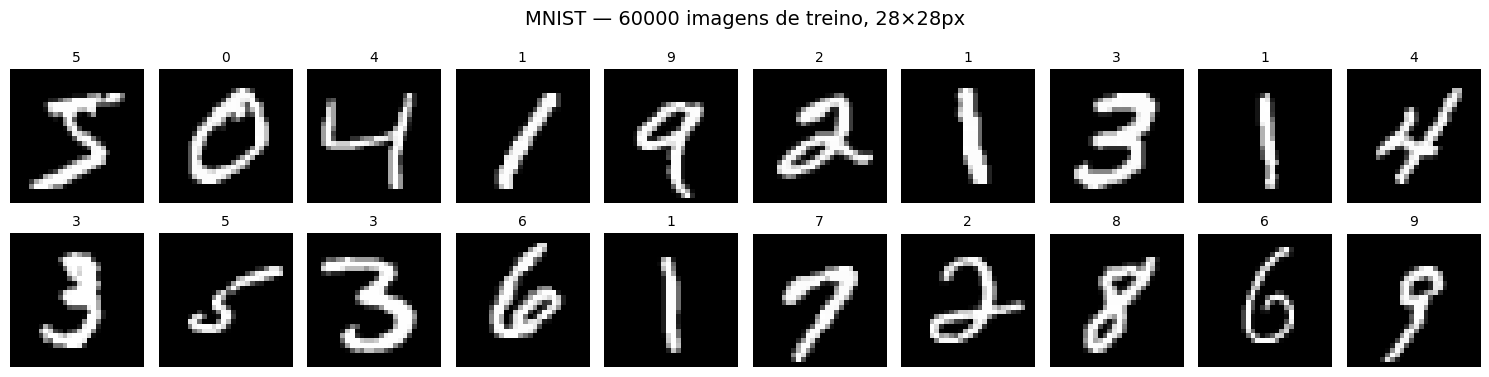

In [2]:
mnist = torchvision.datasets.MNIST(root='/content/data', train=True, download=True,
                                    transform=transforms.ToTensor())

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(20):
    img, label = mnist[i]
    ax = axes[i // 10, i % 10]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(str(label), fontsize=10)
    ax.axis("off")
plt.suptitle(f"MNIST — {len(mnist)} imagens de treino, 28×28px", fontsize=14)
plt.tight_layout()
plt.show()

### 2. CIFAR-10 (Canadian Institute for Advanced Research)

60 mil imagens coloridas, 32×32 pixels, 10 classes de objetos/animais.

100%|██████████| 170M/170M [26:45<00:00, 106kB/s]    


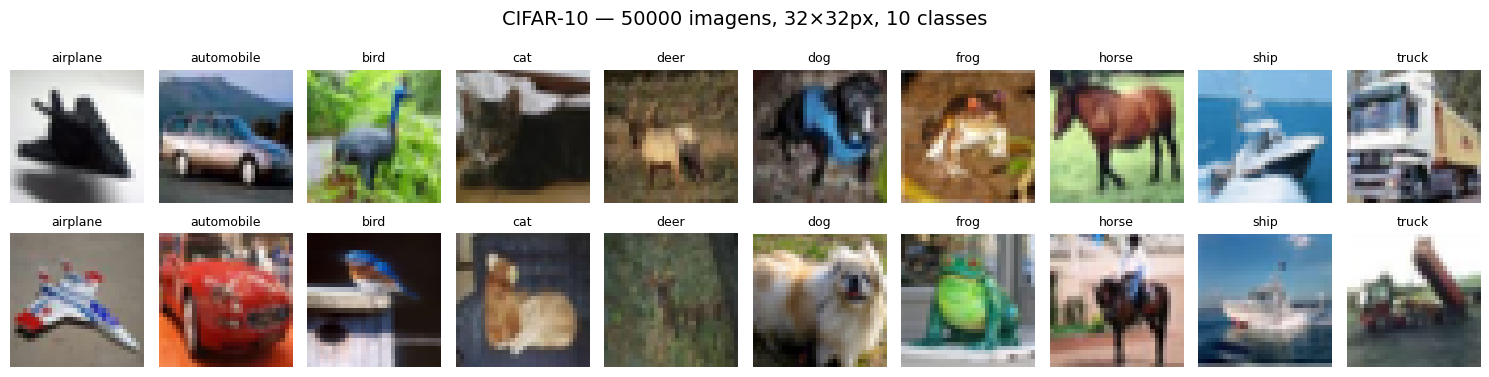

In [3]:
cifar10 = torchvision.datasets.CIFAR10(root='/content/data', train=True, download=True,
                                        transform=transforms.ToTensor())
classes_cifar = cifar10.classes

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
shown = {c: 0 for c in range(10)}
idx = 0
for img, label in cifar10:
    if shown[label] < 2:
        row = shown[label]
        axes[row, label].imshow(img.permute(1, 2, 0))
        axes[row, label].set_title(classes_cifar[label], fontsize=9)
        axes[row, label].axis("off")
        shown[label] += 1
    if all(v >= 2 for v in shown.values()):
        break
plt.suptitle(f"CIFAR-10 — {len(cifar10)} imagens, 32×32px, 10 classes", fontsize=14)
plt.tight_layout()
plt.show()

### 3. ImageNet

1.3 milhão de imagens, 1000 classes, resolução variada. O dataset que detonou a revolução!

> 📝 Em 2012, a **AlexNet** venceu o desafio ImageNet com margem enorme, usando CNN + GPU. Foi o "Big Bang" do Deep Learning.

## Os 3 Avanços Tecnológicos

| Avanço | O que faz | Por que importa |
|--------|-----------|-----------------|
| **Backpropagation** | Calcula gradientes pra atualizar pesos | Sem ele, a rede não aprende |
| **ReLU** | `f(x) = max(0, x)` | Mais rápida que sigmoide, resolve vanishing gradients |
| **GPUs** | Processamento paralelo matricial | Treinar redes grandes em tempo viável |

## Prática — Estatísticas dos Datasets

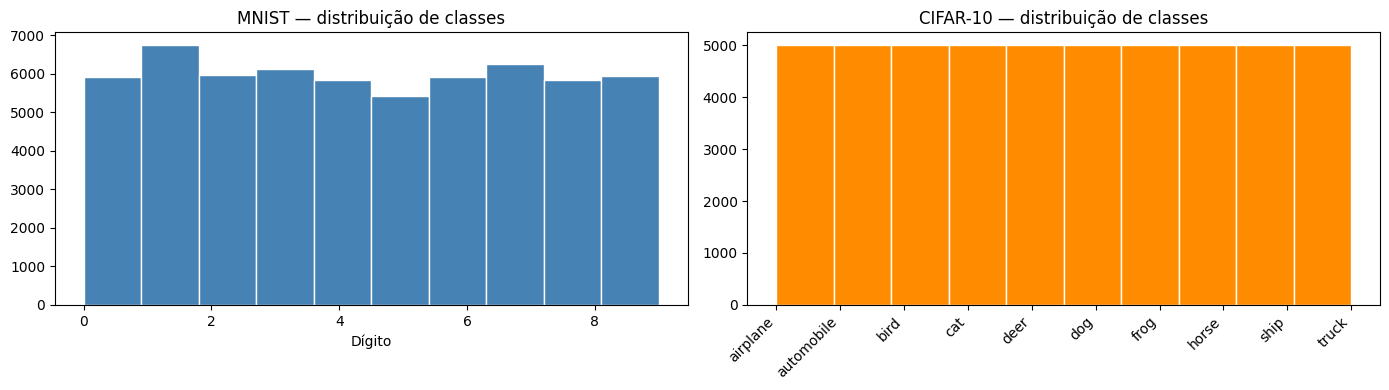

Contagem de amostras por classe no MNIST:
  - Classe 0: 5923 amostras
  - Classe 1: 6742 amostras
  - Classe 2: 5958 amostras
  - Classe 3: 6131 amostras
  - Classe 4: 5842 amostras
  - Classe 5: 5421 amostras
  - Classe 6: 5918 amostras
  - Classe 7: 6265 amostras
  - Classe 8: 5851 amostras
  - Classe 9: 5949 amostras

Contagem de amostras por classe no CIFAR-10:
  - airplane  : 5000 amostras
  - automobile: 5000 amostras
  - bird      : 5000 amostras
  - cat       : 5000 amostras
  - deer      : 5000 amostras
  - dog       : 5000 amostras
  - frog      : 5000 amostras
  - horse     : 5000 amostras
  - ship      : 5000 amostras
  - truck     : 5000 amostras


In [4]:
# Distribuição de classes no MNIST
# Usamos .targets (rótulos já prontos) em vez de iterar mnist[i], que decodificaria
# as 60k imagens só pra pegar o label — muito mais rápido e dá o mesmo resultado.
mnist_labels = mnist.targets.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(mnist_labels, bins=10, color='steelblue', edgecolor='white')
axes[0].set_title("MNIST — distribuição de classes")
axes[0].set_xlabel("Dígito")

cifar_labels = cifar10.targets  # lista de rótulos já pronta (sem decodificar imagens)
axes[1].hist(cifar_labels, bins=10, color='darkorange', edgecolor='white')
axes[1].set_xticks(range(10))
axes[1].set_xticklabels(classes_cifar, rotation=45, ha='right')
axes[1].set_title("CIFAR-10 — distribuição de classes")

plt.tight_layout()
plt.show()

# Contar classes
mnist_counts = np.bincount(mnist_labels)
cifar_counts = np.bincount(cifar_labels)

print("Contagem de amostras por classe no MNIST:")
for i, count in enumerate(mnist_counts):
    print(f"  - Classe {i}: {count} amostras")

print("\nContagem de amostras por classe no CIFAR-10:")
for i, count in enumerate(cifar_counts):
    print(f"  - {classes_cifar[i]:10s}: {count} amostras")

> 📝 Ambos os datasets são **balanceados** (mesma quantidade por classe). Isso facilita o treinamento mas não é sempre o caso no mundo real!

## ✅ Atividades Complementares

### Visualizar um único dígito como array numérico

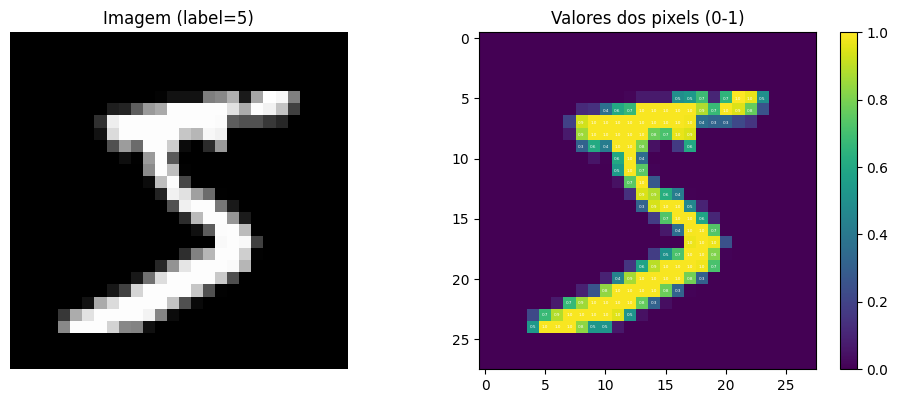

Shape: (28, 28), Min: 0.00, Max: 1.00


In [5]:
img, label = mnist[0]
arr = img.squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(arr, cmap='gray')
axes[0].set_title(f"Imagem (label={label})")
axes[0].axis("off")

# Mostrar valores dos pixels como heatmap
im = axes[1].imshow(arr, cmap='viridis')
axes[1].set_title("Valores dos pixels (0-1)")
for i in range(28):
    for j in range(28):
        if arr[i, j] > 0.3:
            axes[1].text(j, i, f'{arr[i,j]:.1f}', ha='center', va='center', fontsize=3, color='white')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

print(f"Shape: {arr.shape}, Min: {arr.min():.2f}, Max: {arr.max():.2f}")